In [ ]:
import sys
if "tf_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import torch
from torch.utils.data import TensorDataset  # 数据集对象
from torch.utils.data import DataLoader     # 数据加载器
import torch.nn as nn
import torch.optim as optim                 # 优化器
from sklearn.model_selection import train_test_split    # 训练集和测试集的划分
from torchsummary import summary            # 观察神经网络
import time 

环境配置正常


In [2]:
def tensor_print(t , num=0):
    print(f"{t} , type:{type(t)}" , end='')
    try:
        print(f' row:{t.shape[0]} , columns:{t.shape[1]} , last:{t.shape[-1]}')
    except Exception as e:
        print('t.shape:',t.shape)        
    if num != 0:
        print('-' * 15,end='')
        print(f' 第{num}项如上',end='')
        print('-' * 15)
    else:
        print('-'*30)

<font color = #000000 >

## 1-0 图像相关基础





</font>

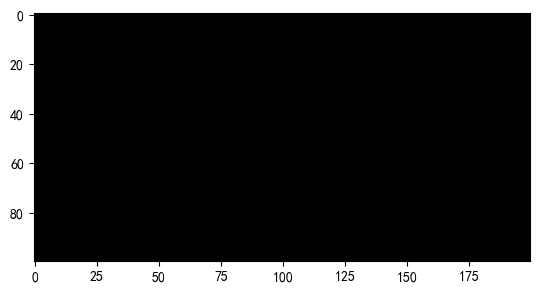

In [9]:
# 1. 绘制全黑全白图

# 1-1 定义全黑图片
img = np.zeros((100,200,3)) # ones为全白(0对应黑色,1对应全白)

# 1-2 展示图片
plt.imshow(img)
plt.show()

<font color = #000000 >

## 1-1 卷积层-概念介绍

+ CNN介绍
    + 卷积层负责提取图像中的局部特征；
    + 池化层用来大幅降低参数量级（降维）；
    + 全连接层用来输出想要的结果。

+ 填充(padding):
    + 通过上面的卷积计算过程，最终的特征图比原始图像小很多，如果想要保持经过卷积后的图像大小不变，可以在原图周围添加 padding 来实现。
    + padding（填充）操作用于处理卷积时图像边缘的像素。
    + 其目的是在输入图像的边界周围添加额外的像素（`通常是零`），从而解决卷积操作时边缘信息丢失的问题。

+ 步长(Stride)
    + stride（步长）指的是卷积核在图像上滑动时的步伐大小，即每次卷积时卷积核在图像中向右（或向下）移动的像素数。
    + 步长直接影响卷积操作后输出特征图的尺寸，以及计算量和模型的特征提取能力。

+ 多通道卷积计算
    + 卷积计算是对应计算(*而不是@),计算结果相加
<p align="center"><img src="CNN神经网络.assets/2026-03-21-12-45-11.png" style="width:60%;"></p>

+ 多卷积核卷积计算
    + 记得加偏置

<p align="center"><img src="CNN神经网络.assets/2026-03-21-12-50-13.png" style="width:60%;"></p>

+ 特征图计算规则
    + 特征图大小(N) = ( W(原图大小) - F(卷积核大小) + 2P(填充,padding) ) / S(步长)  +  1

<p align="center"><img src="CNN神经网络.assets/2026-03-21-12-54-58.png" style="width:60%;"></p>

</font>

<font color = #000000 >

## 1-2 卷积层-API介绍



</font>

(640, 640, 3)
torch.Size([3, 640, 640])
torch.Size([1, 3, 640, 640])
torch.Size([1, 4, 319, 319])
torch.Size([4, 319, 319])
torch.Size([319, 319, 4])
(319, 319)


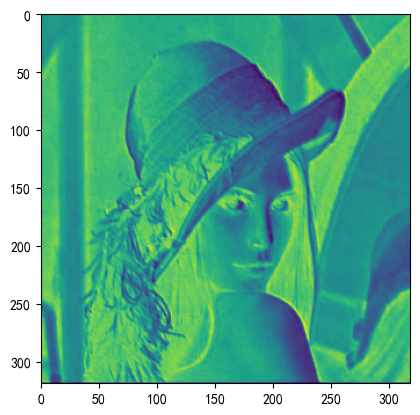

In [ ]:
# 1. 加载RGB图
img = plt.imread('./lena.jpg')
print(img.shape)

# 2. 把图像的形状从 HWC 变成 CHW (变成3x640x640) 思路: img -> 张量 -> 转换维度
img2 = torch.tensor(img , dtype=torch.float)
img2 = img2.permute(2,0,1)
print(img2.shape)

# 3. 因为这里只有一张图，所以再增加维度,从 CHW -> (1,C ,H ,W),一张3通道的  640*640像素的图
img3 = img2.unsqueeze(dim=0)    # 这样后面可以构造图片集
print(img3.shape)

# 4. 创建卷积层对象
# in/out_channels: 输入/出通道数(in_channels个通道 / out_channels个特征图)
conv = nn.Conv2d(in_channels=3 , out_channels=4 ,kernel_size=3, stride= 2 , padding=0)

# 5. 具体的卷积计算
conv_img = conv(img3)

# 6. 打印卷积后的结果
print(conv_img.shape)

# 7. 处理特征图
img4 = conv_img[0]  # 得到CHW
print(img4.shape)
img5 = img4.permute(1,2,0)  # 得到HWC
print(img5.shape)

# 8. 可视化
feature1 = img5[:,:,0].detach().numpy() # 一共4个
print(feature1.shape)
plt.imshow(feature1)

<font color = #000000 >

## 2-1 池化层-概念介绍

+ 降低维度,从而减少计算量
+ 池化层通常位于卷积层之后，它通过对卷积层输出的特征图进行下采样，保留最重要的特征信息，同时丢弃一些不重要的细节。
    + 最大池化(常用)
    + 平均池化
+ 池化不会改变通道数(因为卷积会将各个通道的输入相加，但是池化不会相加)

+ `最大池化演示`
<p align="center"><img src="CNN神经网络.assets/2026-03-21-13-24-49.png" style="width:60%;"></p>

</font>

<font color = #000000 >

## 2-2 池化层-API



</font>

In [ ]:
# 1. 单通道
# 1-1 创建1个 1通道的 3*3的二维矩阵
inputs = torch.tensor([ # C:1
    [  # 3  
        [0,1,2], # 3 
        [3,4,5],
        [6,7,8]
    ]
])
print(inputs.shape) # CHW 

# 1-2 创建最大池化层
pool1 = nn.MaxPool2d(kernel_size=2,stride=1,padding=0)
outputs = pool1(inputs)
print(outputs.shape)

# 1-3 创建平均池化层
pool2 = nn.AvgPool2d(kernel_size=2,stride=1,padding=0)
outputs = pool2(inputs)
print(outputs.shape)

torch.Size([1, 3, 3])
torch.Size([1, 2, 2])
torch.Size([1, 2, 2])


In [28]:
# 2. 多通道
# 2-1 创建1个 3通道的 3*3的二维矩阵
inputs = torch.tensor([ # C:3
    [  # 3  
        [0,1,2], # 3 
        [3,4,5],
        [6,7,8]
    ],

    [  # 3  
        [10,11,12], # 3 
        [13,14,15],
        [16,17,18]
    ],

    [  # 3  
        [10,11,21], # 3 
        [31,41,51],
        [61,71,81]
    ]
])
print(inputs.shape) # CHW 

# 2-2 创建最大池化层
pool1 = nn.MaxPool2d(kernel_size=2,stride=1,padding=0)
outputs = pool1(inputs)
print(outputs.shape)

# 2-3 创建平均池化层
pool2 = nn.AvgPool2d(kernel_size=2,stride=1,padding=0)
outputs = pool2(inputs)
print(outputs.shape)

torch.Size([3, 3, 3])
torch.Size([3, 2, 2])
torch.Size([3, 2, 2])
